### Desafio de ciência de dados:

In [8]:
import pandas as pd

Extraindo os dados para o data_frame

In [9]:
data_frame = pd.read_csv('vendas_loja_dataset.csv')

Visualizando colunas existentes e os últimos 5 registros do data_frame

In [10]:
data_frame.columns

Index(['VendaID', 'Data', 'Cliente', 'Cidade', 'Produto', 'Categoria',
       'Quantidade', 'Valor_Unitario', 'Valor_Total', 'Pagamento'],
      dtype='str')

In [11]:
data_frame.tail()

,VendaID,Data,Cliente,Cidade,Produto,Categoria,Quantidade,Valor_Unitario,Valor_Total,Pagamento
495,496,12/02/2026,Ana,Porto Velho,Headset,Informática,1,845.13,845.13,Pix
496,497,08/01/2026,Pedro,Rio Branco,Mouse,Informática,4,140.10,560.40,Cartão
497,498,04/04/2026,Bruno,Rio Branco,Monitor,Informática,2,1158.81,2317.62,Cartão
498,499,29/04/2026,João,Porto Velho,Monitor,Informática,1,726.04,726.04,Pix
499,500,12/01/2026,Bianca,Porto Velho,Notebook,Informática,4,4569.05,18276.20,Cartão


#### 1ª Pegunta

In [12]:
print('Cidade que mais fez vendas:', data_frame['Cidade'].max())

Cidade que mais fez vendas: Rio Branco


#### 2ª Pegunta

In [13]:
print('Produto que mais vendeu:', data_frame['Produto'].max())

Produto que mais vendeu: Teclado


#### 3ª Pegunta

In [14]:
print('Método de pagamento mais utilizado:', data_frame['Pagamento'].max())

Método de pagamento mais utilizado: Pix


#### 4ª Pegunta

In [15]:
print('Total faturado pela empresa: R$', data_frame['Valor_Total'].sum())

Total faturado pela empresa: R$ 1498016.55


#### 5ª Pegunta

In [16]:
print('Dados da maior venda realizada:')
data_frame.loc[data_frame['Valor_Total'].idxmax(), ['VendaID', 'Produto', 'Cidade', 'Pagamento', 'Valor_Total', 'Quantidade']]

Dados da maior venda realizada:


VendaID               332
Produto          Notebook
Cidade         Rio Branco
Pagamento             Pix
Valor_Total      25909.04
Quantidade              4
Name: 331, dtype: object

#### 6ª Pegunta

In [17]:
print('Dados da menor venda realizada:')
data_frame.loc[data_frame['Valor_Total'].idxmin(), ['VendaID', 'Produto', 'Cidade', 'Pagamento', 'Valor_Total']]

Dados da menor venda realizada:


VendaID            61
Produto         Mouse
Cidade          Belém
Pagamento      Boleto
Valor_Total     44.25
Name: 60, dtype: object

#### 7ª Pergunta

In [18]:
print('Quantidade de produtos únicos:', data_frame['Produto'].nunique())
print('Lista de produtos únicos:', data_frame['Produto'].unique())

Quantidade de produtos únicos: 7
Lista de produtos únicos: <StringArray>
['Monitor', 'Impressora', 'Teclado', 'Headset', 'Notebook', 'Mouse', 'SSD']
Length: 7, dtype: str


#### 8ª Pergunta

In [19]:
print('Categoria do produto que mais vendeu:')
data_frame.loc[data_frame['Valor_Total'].idxmax(), ['Categoria']]

Categoria do produto que mais vendeu:


Categoria    Informática
Name: 331, dtype: str

#### 9ª Pergunta

In [20]:
print('Cidade que mais gerou faturamento:')
data_frame.loc[data_frame['Valor_Total'].idxmax(), ['Valor_Total', 'Cidade']]

Cidade que mais gerou faturamento:


Valor_Total      25909.04
Cidade         Rio Branco
Name: 331, dtype: object

#### 10ª Pergunta

In [21]:
print('Produto mais vendido:')
data_frame.loc[(data_frame['Produto'] == data_frame['Produto'].value_counts().idxmax()) & (data_frame['Cidade'] == 'Boa Vista'), ['Produto', 'Quantidade']]

Produto mais vendido:


,Produto,Quantidade
12,Mouse,2
18,Mouse,2
34,Mouse,1
109,Mouse,3
149,Mouse,1
157,Mouse,1
159,Mouse,3
168,Mouse,1
197,Mouse,2
206,Mouse,2


In [22]:
print('Clientes por cidade:')
data_frame.groupby('Valor_Total')['Cliente'].nunique().sort_values(ascending=False)

Clientes por cidade:


Valor_Total
560.40      2
48.93       1
11200.78    1
117.52      1
44.25       1
           ..
104.00      1
108.33      1
109.62      1
114.53      1
45.98       1
Name: Cliente, Length: 499, dtype: int64

In [23]:
print('Faturamento por cidade: R$')
data_frame.groupby('Cidade')['Valor_Total'].sum().sort_values(ascending=False)

Faturamento por cidade: R$


Cidade
Rio Branco     345796.40
Porto Velho    326262.95
Belém          282912.03
Manaus         276489.04
Boa Vista      266556.13
Name: Valor_Total, dtype: float64

In [24]:
print('Vendas por cidade: R$')
data_frame.groupby('Cidade')['VendaID'].count().sort_values(ascending=False)

Vendas por cidade: R$


Cidade
Belém          106
Rio Branco     103
Boa Vista       98
Porto Velho     97
Manaus          96
Name: VendaID, dtype: int64

In [25]:
print('Quantidade de produtos por cidade:')
data_frame.groupby(['Cidade'])['Produto'].value_counts().sort_values(ascending=True)

cidades = data_frame['Cidade'].unique()

for cidade in cidades:
    print(f'Quantidade de produtos vendidos na cidade {cidade}:')
    print(data_frame.loc[data_frame['Cidade'] == cidade].groupby('Produto')['Quantidade'].sum().sort_values(ascending=False))



Quantidade de produtos por cidade:
Quantidade de produtos vendidos na cidade Manaus:
Produto
Mouse         44
Teclado       40
SSD           36
Monitor       34
Headset       33
Impressora    27
Notebook      26
Name: Quantidade, dtype: int64
Quantidade de produtos vendidos na cidade Rio Branco:
Produto
Teclado       56
Monitor       52
Notebook      37
SSD           31
Mouse         29
Headset       27
Impressora    24
Name: Quantidade, dtype: int64
Quantidade de produtos vendidos na cidade Porto Velho:
Produto
Impressora    46
Teclado       42
Monitor       41
Notebook      37
SSD           32
Headset       20
Mouse         20
Name: Quantidade, dtype: int64
Quantidade de produtos vendidos na cidade Belém:
Produto
Headset       53
Mouse         42
SSD           40
Monitor       39
Impressora    38
Teclado       29
Notebook      27
Name: Quantidade, dtype: int64
Quantidade de produtos vendidos na cidade Boa Vista:
Produto
Mouse         53
Headset       37
Teclado       36
Monitor      

In [26]:
print('Valor de produtos por cidade:')
data_frame.groupby(['Cidade'])['Valor_Unitario'].value_counts().sort_values(ascending=True)

cidades = data_frame['Cidade'].unique()

for cidade in cidades:
    print(f'Quantidade de produtos vendidos na cidade {cidade}:')
    print(data_frame.loc[data_frame['Cidade'] == cidade].groupby('Produto')['Quantidade'].sum().sort_values(ascending=False))

Valor de produtos por cidade:
Quantidade de produtos vendidos na cidade Manaus:
Produto
Mouse         44
Teclado       40
SSD           36
Monitor       34
Headset       33
Impressora    27
Notebook      26
Name: Quantidade, dtype: int64
Quantidade de produtos vendidos na cidade Rio Branco:
Produto
Teclado       56
Monitor       52
Notebook      37
SSD           31
Mouse         29
Headset       27
Impressora    24
Name: Quantidade, dtype: int64
Quantidade de produtos vendidos na cidade Porto Velho:
Produto
Impressora    46
Teclado       42
Monitor       41
Notebook      37
SSD           32
Headset       20
Mouse         20
Name: Quantidade, dtype: int64
Quantidade de produtos vendidos na cidade Belém:
Produto
Headset       53
Mouse         42
SSD           40
Monitor       39
Impressora    38
Teclado       29
Notebook      27
Name: Quantidade, dtype: int64
Quantidade de produtos vendidos na cidade Boa Vista:
Produto
Mouse         53
Headset       37
Teclado       36
Monitor       34
I

In [27]:
data_frame.groupby('Cidade')['Valor_Total'].mean()

Cidade
Belém          2668.981415
Boa Vista      2719.960510
Manaus         2880.094167
Porto Velho    3363.535567
Rio Branco     3357.246602
Name: Valor_Total, dtype: float64

In [29]:
data_frame.loc[data_frame['Quantidade'].idxmax(), ['Produto', 'Cidade']]

Produto        Teclado
Cidade     Porto Velho
Name: 2, dtype: str

In [50]:
# Agrupa por produto e soma a quantidade
data_frame.groupby('Produto')['Quantidade'].sum().reset_index().sort_values('Quantidade', ascending=False)


,Produto,Quantidade
6,Teclado,203
2,Monitor,200
3,Mouse,188
0,Headset,170
1,Impressora,163
5,SSD,155
4,Notebook,152


In [ ]:
# Valor médio por produto.
data_frame.groupby('Produto')['Valor_Unitario'].mean().reset_index().sort_values('Valor_Unitario', ascending=False)

,Produto,Valor_Unitario
4,Notebook,5160.546716
2,Monitor,1482.802763
1,Impressora,1197.198261
5,SSD,494.062462
0,Headset,492.106613
6,Teclado,208.539500
3,Mouse,108.720247


<Axes: title={'center': 'Quantidade de vendas por cidade'}, xlabel='Cidade'>

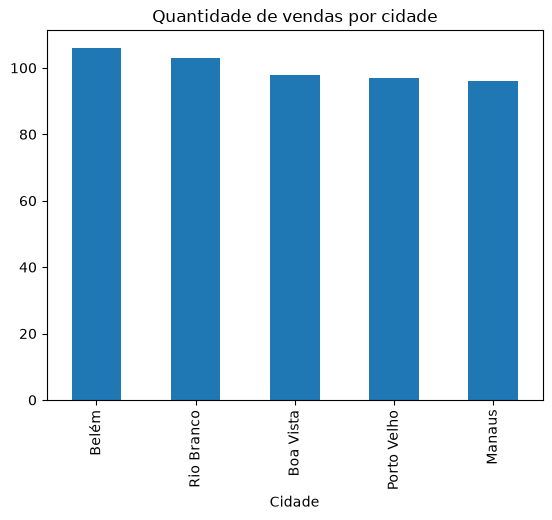

In [54]:
data_frame['Cidade'].value_counts().plot(kind='bar', title='Quantidade de vendas por cidade')

In [61]:
# Lista todos os valores unitários diferentes de cada produto
precos_unicos = data_frame.groupby('Produto')['Valor_Unitario'].unique().reset_index()
print(precos_unicos)

      Produto                                     Valor_Unitario
0     Headset  [403.76, 273.54, 152.46, 665.93, 760.2, 390.49...
1  Impressora  [909.7, 1741.95, 1223.07, 695.32, 1022.97, 805...
2     Monitor  [840.05, 1033.39, 1775.27, 1982.92, 920.64, 22...
3       Mouse  [124.41, 123.21, 135.71, 142.86, 50.43, 99.34,...
4    Notebook  [4020.99, 3857.49, 4932.56, 5175.21, 5505.88, ...
5         SSD  [687.16, 458.99, 755.71, 683.19, 382.69, 652.0...
6     Teclado  [130.6, 108.79, 344.81, 184.5, 112.51, 153.24,...


In [62]:
# Mostra o menor, o maior e o preço médio de cada produto
resumo_precos = data_frame.groupby('Produto')['Valor_Unitario'].agg(['min', 'max', 'mean']).reset_index()
print(resumo_precos)

      Produto      min      max         mean
0     Headset   152.37   880.94   492.106613
1  Impressora   527.70  1782.91  1197.198261
2     Monitor   726.04  2493.36  1482.802763
3       Mouse    41.58   179.84   108.720247
4    Notebook  3526.71  6477.26  5160.546716
5         SSD   182.98   771.61   494.062462
6     Teclado    80.19   344.81   208.539500


In [63]:
precos_impressora = data_frame[data_frame['Produto'] == 'Impressora']['Valor_Unitario'].unique()

print(precos_impressora)

[ 909.7  1741.95 1223.07  695.32 1022.97  805.5   974.27 1023.49 1492.35
  618.62 1692.86 1344.76 1315.51 1533.88  975.92  733.14 1622.3  1530.43
 1320.35 1619.67 1371.    618.81 1520.36 1712.11 1400.23 1745.36 1257.49
  806.59 1442.89 1745.48 1164.91 1782.91 1161.38  927.08 1632.28 1283.33
 1300.46  755.63 1690.56  782.16 1031.02 1105.94  945.33  770.42 1778.08
  810.81 1422.3  1405.96 1379.22 1223.97  985.9   720.5   759.04  738.63
  850.08 1275.67 1733.53 1130.45  907.71  868.63 1058.99 1621.2   527.7
  893.19 1012.22 1094.63 1248.69 1332.78 1677.01]
